<a href="https://colab.research.google.com/github/MarlonSC14/Hyperparameter-search-in-XGBoost/blob/colab_code/hyperparameter_search_in_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective of this notebook is to study different kinds of hyperparameter search included in the sklearn library for an XGBoost classification problem.

# Setup

Installing the specific versions of the libraries that we will need throughout the code, importing them and cloning/importing a repository with auxiliary scripts.

**Important: If you are running the code in Google Colab, make sure to switch the runtime type to T4 GPU.**

In [1]:
!pip install mplhep
!pip install matplotlib==3.1.3
!pip install xgboost==3.3.0

  Using cached matplotlib-3.1.3.tar.gz (40.9 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, recall_score, precision_score, auc, precision_recall_curve
from hyperopt import fmin, hp, tpe, STATUS_OK
import pprint
import seaborn as sns
import os
import sys

In [3]:
!git clone https://github.com/horace-cl/scripts # Importing the contents from this github repository to use some auxiliary (important) python scripts
sys.path.append('/content/scripts') # Adding the cloned folder to the system path

fatal: destination path 'scripts' already exists and is not an empty directory.


In [4]:
# Importing a custom function from the auxiliary scripts imported from git
from plot_tools_xgb import plot_classifier_distributions

# Importing data

For this github repository, only a zip file with a sample of the data is displayed. In order to use it, you must unzip it and download it.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Path where the data is
path_ = 'drive/MyDrive/portafolios_git/XGB_hyperparameters/'

In [7]:
# You will need to decompress the zip sample data and download it to use it.
# Originally this DataFrames had 4002800 entries (background) and 40028 entries (signal). Since this is a demonstrative public exercise, a sample of 5% was taken for background and 15% for signal.
LR=pd.read_pickle(path_+'sample_XGB_left_right_4040_all.pkl') # Importing background data
S= pd.read_pickle(path_+'sample_XGB_signal_4040_all.pkl') # Importing signal data

# Defining functions

In [8]:
# Defining a function to plot feature importance
# The function needs the importances, the names of the features and the model type

#Add it to own scripts folder
def plot_feature_importance(importance,names,model_type):

  #Creating arrays from feature importance and feature names
  feature_importance = np.array(importance)
  feature_names = np.array(names)

  #Creating a DataFrame using a Dictionary
  data={'feature_names':feature_names,'feature_importance':feature_importance}
  fi_df = pd.DataFrame(data)

  #Sort the DataFrame in order decreasing feature importance
  fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

  pprint.pprint(dict(zip(fi_df['feature_names'],fi_df['feature_importance'])))

  #Define size of bar plot
  plt.figure(figsize=(10,8))
  #Plot Searborn bar chart
  sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
  #Add chart labels
  plt.title(model_type + ' FEATURE IMPORTANCE')
  plt.xlabel('FEATURE IMPORTANCE')
  plt.ylabel('FEATURE NAMES')

In [9]:
# Defining a function to plot a correlation heatmap for the features
# The function only needs the training pandas DataFrame

#Add it to own scripts folder
def correlation_heatmap(train):

  # Obtaining the correlation between colmns of the DataFrame
  correlations = train.corr()

  # Plotting the correlation heatmap using the heatmap function of the seaborn library
  fig, ax = plt.subplots(figsize=(10,10))
  sns.heatmap(correlations, vmax=1.0, center=0, fmt='.2f', cmap="YlGnBu",
              square=True, linewidths=.5, cbar_kws={"shrink": .70}, annot=True, annot_kws={"size": 35 / np.sqrt(len(correlations))}
              )
  plt.show();

In [10]:
# Defining the recall metric
# This function is built to work with XGB models and fittings

#Add it to own scripts folder
def recall_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    err = recall_score(y_true, np.round(y_pred), average='weighted', zero_division=0)
    return 'recall_err', err

In [11]:
# Defining the precision metric
# This function is built to work with XGB models and fittings

#Add it to own scripts folder
def precision_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    err = precision_score(y_true, np.round(y_pred), average='weighted', zero_division=0)
    return 'precision_err', err

In [12]:
# This function plots a precision-recall curve and displays the aucpr values for train and test datasets in classification

#Add it to own scripts folder
def plot_precision_recall_curve(model, train, test):
  pred_valueste = model.predict_proba(test[cols])[:,1]
  pred_valuestr = model.predict_proba(train[cols])[:,1]
  precisionte, recallte, thresholdste = precision_recall_curve(test['label'], pred_valueste)
  precisiontr, recalltr, thresholdstr = precision_recall_curve(train['label'], pred_valuestr)
  auc_precision_recallte = auc(recallte, precisionte)
  auc_precision_recalltr = auc(recalltr, precisiontr)

  fig, ax = plt.subplots()
  ax.plot(precisionte, recallte, label='Test')
  ax.plot(precisiontr, recalltr, label='Train')
  plt.legend(loc="best")
  ax.set(xlim=(0, 1.1), xticks=np.arange(0, 1.1, 0.1),
          ylim=(0, 1.1), yticks=np.arange(0, 1.1, 0.1))
  ax.set_xlabel('precision')
  ax.set_ylabel('recall')
  plt.text(0,0.6,
          "aucpr test = {}".format(f'{auc_precision_recallte:.4f}'))
  plt.text(0,0.5,
          "aucpr train = {}".format(f'{auc_precision_recalltr:.4f}'))
  plt.grid()

  return fig, ax

In [13]:
#Add it to own scripts folder
def params_to_string(model):
  model.get_params()
  string = ''
  lens = [len(k) for k in model.get_params()]
  max_len = max(lens)
  for k,v in model.get_params().items():
    #string += f'{k+" "*(max_len-len(k))} =  {v}\n'
    string += f'{k} = {v}\n'

  return string

In [38]:
def plot_roc_curve(model, test, train):
  test_xgb_per = model.predict_proba(test[cols])
  train_xgb_per = model.predict_proba(train[cols])

  fpr, tpr, thr_ = roc_curve(test.label, test_xgb_per[:,1])
  auc = roc_auc_score(test.label, test_xgb_per[:,1])
  plt.plot(1-fpr, tpr, label=f'Test = {round(auc,4)}', linewidth=2)

  fpr, tpr, thr_ = roc_curve(train.label, train_xgb_per[:,1])
  auc = roc_auc_score(train.label, train_xgb_per[:,1])
  plt.plot(1-fpr, tpr, label=f'Train = {round(auc,4)}', linewidth=2)

  plt.plot(np.linspace(0,1), 1-np.linspace(0,1), color='red', label='Random choice', ls='--', linewidth=0.5)
  plt.xlabel('Background rejection')
  plt.ylabel('Signal efficiency')
  plt.legend(frameon=True, title='auc')

In [15]:
#Add it to own scripts folder
def plot_classifier_distributions_new(model, test, train, print_params=False, bins=25, figsize=(10, 7)):

    test_background = model.predict_proba(test.query('label==0')[cols])[:,1]
    test_signal     = model.predict_proba(test.query('label==1')[cols])[:,1]
    train_background= model.predict_proba(train.query('label==0')[cols])[:,1]
    train_signal    = model.predict_proba(train.query('label==1')[cols])[:,1]

    test_pred = model.predict_proba(test[cols])[:,1]
    train_pred= model.predict_proba(train[cols])[:,1]

    density = True

    fig, ax = plt.subplots(figsize=figsize)

    background_color = 'red'

    opts = dict(
        range=[0,1],
        bins = bins,
        density = density
    )
    histtype1 = dict(
        histtype='stepfilled',
        linewidth=3,
        alpha=0.45,
    )

    ax.hist(train_background, **opts, **histtype1,
             facecolor=background_color,
             edgecolor=background_color,
             zorder=0)
    ax.hist(train_signal, **opts, **histtype1,
             facecolor='blue',
             edgecolor='blue',
             zorder=1000)

    hist_test_0 = np.histogram(test_background, **opts)
    hist_test_1 = np.histogram(test_signal, **opts)
    bins_mean = (hist_test_0[1][1:]+hist_test_0[1][:-1])/2
    bin_width = bins_mean[1]-bins_mean[0]
    area0 = bin_width*np.sum(test.label==0)
    area1 = bin_width*np.sum(test.label==1)

    opts2 = dict(
          capsize=3,
          ls='none',
          marker='o'
    )

    ax.errorbar(bins_mean, hist_test_0[0],  yerr = np.sqrt(hist_test_0[0]/area0), xerr=bin_width/2,
                 color=background_color, **opts2, zorder=100)
    ax.errorbar(bins_mean, hist_test_1[0],  yerr = np.sqrt(hist_test_1[0]/area1), xerr=bin_width/2,
                 color='blue', **opts2, zorder=10000)

    _ks_back = ks_test.ks_2samp_sci(train_background, test_background)[1]
    _ks_sign = ks_test.ks_2samp_sci(train_signal, test_signal)[1]

    print('Own ks test\n',
          ks_test.ks_2samp_weighted(train_background, test_background)[1],
          ks_test.ks_2samp_weighted(train_signal, test_signal)[1], sep='\n\t')

    auc_test  = roc_auc_score(test.label,test_pred )
    auc_train = roc_auc_score(train.label,train_pred)
    legend_elements = [Patch(facecolor='black', edgecolor='black', alpha=0.4,
                             label=f'Train (auc) : {round(auc_train,8)}'),
                      Line2D([0], [0], marker='|', color='black',
                             label=f'Test (auc) : {round(auc_test,8)}',
                              markersize=25, linewidth=1),
                       Circle((0.5, 0.5), radius=2, color='red',
                              label=f'Background (ks-pval) : {round(_ks_back,8)}',),
                       Circle((0.5, 0.5), 0.01, color='blue',
                              label=f'Signal (ks-pval) : {round(_ks_sign,8)}',),
                       ]

    ax.legend(
              #title='KS test',
              handles=legend_elements,
              #bbox_to_anchor=(0., 1.02, 1., .102),
              loc='upper center',
              ncol=2,
              #mode="expand",
              #borderaxespad=0.,
              frameon=True,
              fontsize=15)

    if print_params:
      ax.text(1.02, 1.02, params_to_string(model),
        transform=ax.transAxes,
      fontsize=13, ha='left', va='top')

    ax.set_yscale('log')
    ax.set_xlabel('XGB output')
    #ax.set_ylim(0.005, 100)

    #plt.savefig(os.path.join(dir_, 'LR_overtrain.pdf'), bbox_inches='tight')

    # del test_background, test_signal
    # del train_background, train_signal
    # del test_pred, train_pred
    return fig, ax

# Working with data

We get information from the datasets and we start to get familiar with the data.

In [ ]:
LR.info() #Getting information from the background DataFrame

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 200140 entries, (np.uint64(319337), np.uint64(1120), np.uint64(977864946), np.int64(6)) to (np.uint64(319579), np.uint64(2453), np.uint64(3823074208), np.int64(1))
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DiMuMass     200140 non-null  float32
 1   BMass        200140 non-null  float32
 2   cosThetaKMu  200140 non-null  float32
 3   Bpt          200140 non-null  float32
 4   kpt          200140 non-null  float32
 5   mu1_pt       200140 non-null  float32
 6   mu2_pt       200140 non-null  float32
 7   PDL          200140 non-null  float32
 8   prob         200140 non-null  float32
 9   cosA         200140 non-null  float32
 10  signLxy      200140 non-null  float32
dtypes: float32(11)
memory usage: 51.3 MB


In [ ]:
S.info(max_cols=120) #Getting information from the signal DataFrame

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6004 entries, (np.float64(2.0), np.uint64(1305), np.uint64(1905317), np.int64(0)) to (np.float64(1.0), np.uint64(53216), np.uint64(5321506), np.int64(0))
Data columns (total 101 columns):
 #    Column                  Non-Null Count  Dtype  
---   ------                  --------------  -----  
 0    Bpt                     6004 non-null   float32
 1    fit_eta                 6004 non-null   float32
 2    fit_phi                 6004 non-null   float32
 3    BMass                   6004 non-null   float32
 4    PDL                     6004 non-null   float32
 5    ePDL                    6003 non-null   float32
 6    cosThetaKMu             6004 non-null   float32
 7    prob                    6004 non-null   float32
 8    lxy_proj_significance   6003 non-null   float32
 9    signLxy                 6003 non-null   float32
 10   cosA                    6004 non-null   float32
 11   fit_cos2D               6004 non-null   float32
 12   

Plotting a histogram of the "BMass" feature of the DataFrames. This feature is the key to identify signal and background.

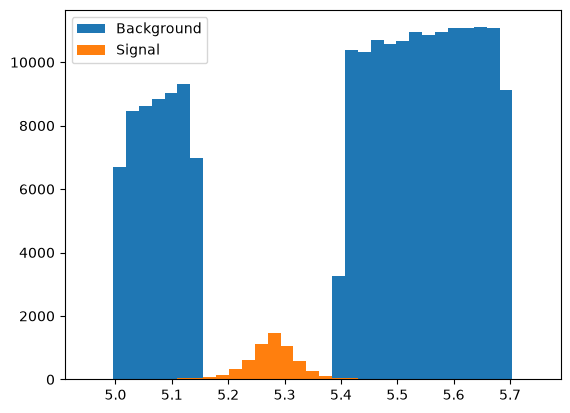

In [ ]:
opts = dict(range=[4.95,5.75], bins=35, density=False) # Personalizing the histogram
plt.hist(LR.BMass, label='Background', **opts) # Creating a histogram for the BMass feature in the background dataset
plt.hist(S.BMass, label='Signal', **opts) # Creating a histogram for the BMass feature in the signal dataset
plt.legend()
plt.show() # Plotting both histograms in the same graph

In [16]:
cols=['Bpt', 'kpt', 'PDL', 'prob', 'cosA', 'signLxy'] # Selecting the columns to work with in this exercise

In [17]:
# We mix both DataFrames in order to create our XGB model
LR['label'] = 0
S['label'] = 1 # Labeling the signal and Background DataFrames
total = pd.merge(S[cols+['label']],LR[cols+['label']],how='outer') # Merging signal and background DataFrames
train, test = train_test_split(total, test_size=0.3, random_state=1) # Using the train_test_split method from sklearn to get a training and a testing DataFrame (in this case we split 70% train and 30% test)
sample_size = total.shape[0] # Obtaining the size of the merged dataframe

In [18]:
# Defining the evaluation set to train the data in the following sections
evaluation= [(train[cols], train['label']),(test[cols],test['label'])]

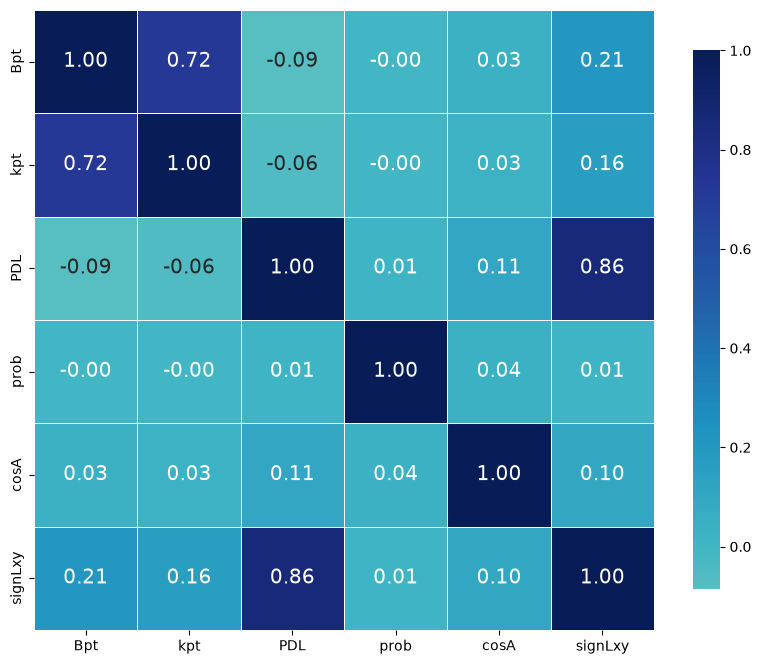

In [ ]:
# This is a functon that plots a heatmap of the correlations between features (columns) in our dataset.
# Depending on how correlated these features are, we might decide to discard some of them. In this case we conserve all columns (6).
correlation_heatmap(S[cols])

# **Recall metric**

### First XGB recall model

In [ ]:
# Creating an XGBoost model
model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain' # Dictates the metric to calculate feature importance
                      )

In [ ]:
# Defining some parameters from our model. It is mandatory to define these parameters this way and not into the definition of the classifier since we are using a custom metric
# Using the recall metric defined previously
#early_stopping_rounds is a parameter that stops model training when the performance on the validation dataset stops improving
model_recall.set_params(custom_metric = recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [ ]:
# Training the model with our data using the recall metric
model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

{'Bpt': 0.021353496238589287,
 'PDL': 0.020199788734316826,
 'cosA': 0.6167211532592773,
 'kpt': 0.18459674715995789,
 'prob': 0.037120237946510315,
 'signLxy': 0.12000858038663864}


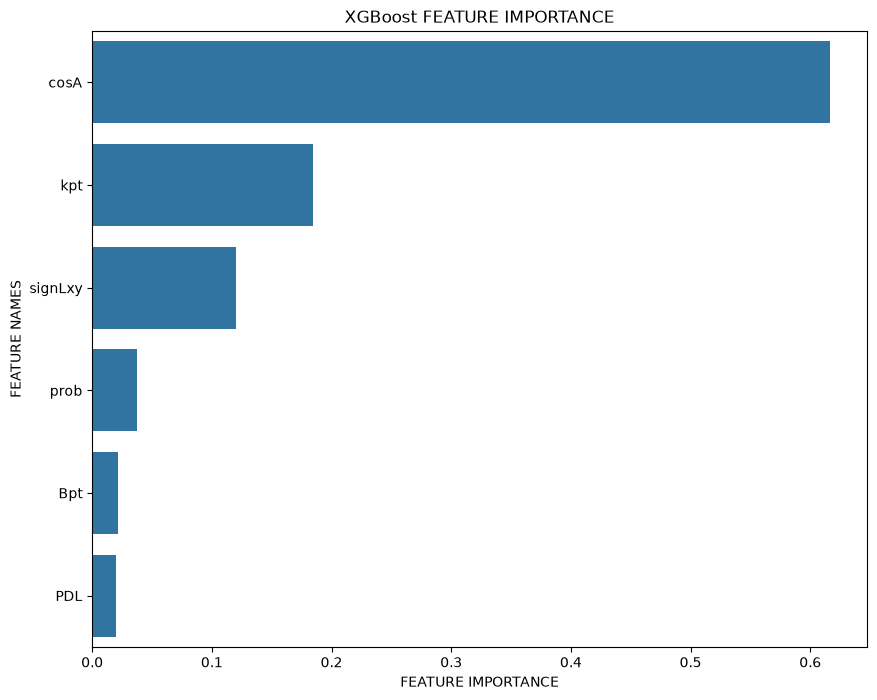

In [ ]:
# This is a functin that plots a histogram of the importance of the features (columns) that we are working with. In this case, we specified to calculate the importance with the "gain" metric in this model.
plot_feature_importance(model_recall.feature_importances_, train[cols].columns, "XGBoost")

**Evaluating our model**

In [ ]:
#Adding the probabilities for the events to be signal in the test and train DataFrames to a column and creating new dataframes with this column.
#This is done in order to work with the next function
test_prov = test.assign(XGB=model_recall.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=model_recall.predict_proba(train[cols])[:,1])

Own ks test

	0.8560873777461462
	0.05659666627921


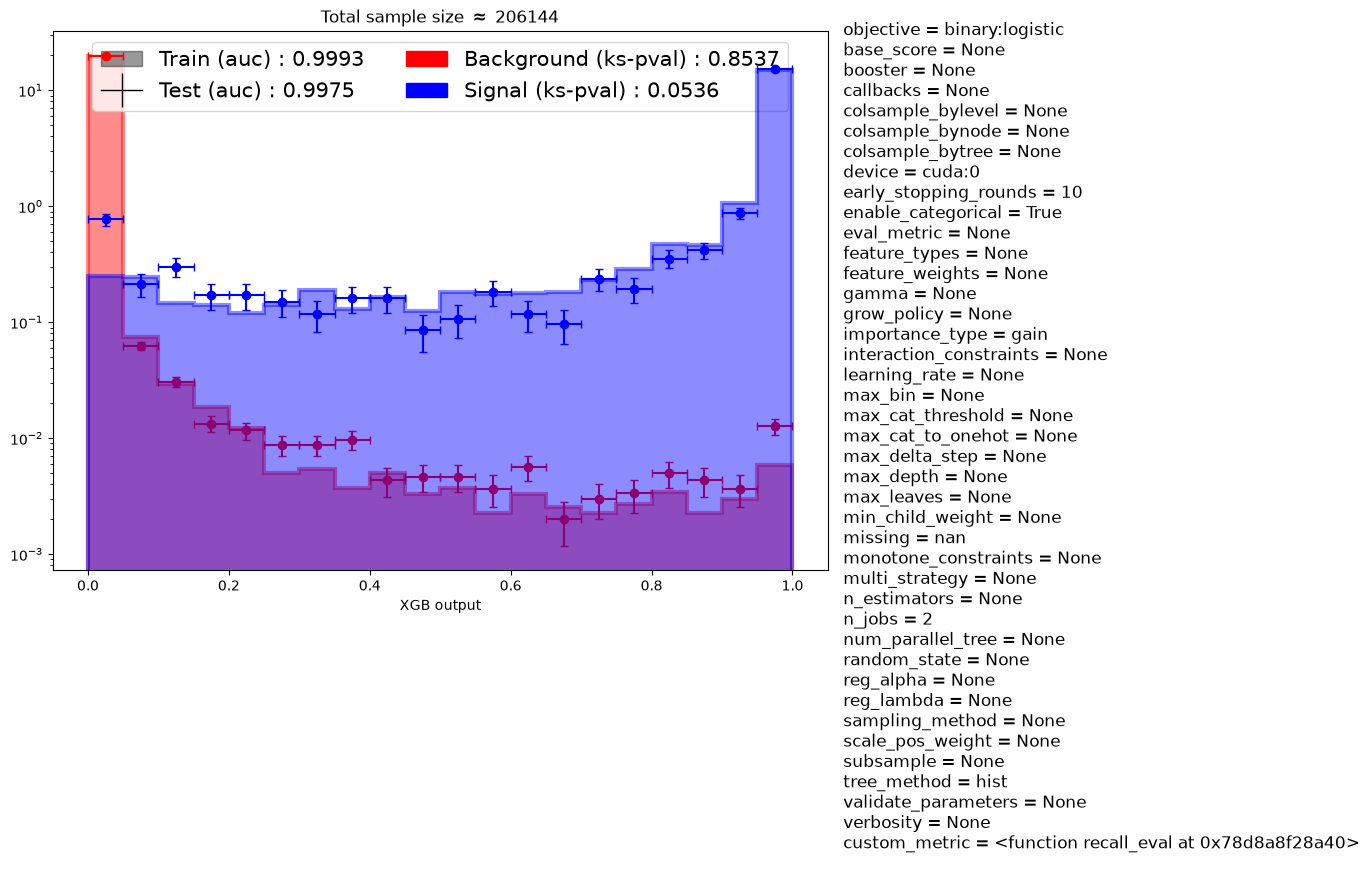

In [ ]:
# The plot_classifier_distributions function plots histograms for the train and test DataFrames for signal and background. Then returns the pvalues for each set using ks test
fig, ax = plot_classifier_distributions(model_recall, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for recall model')

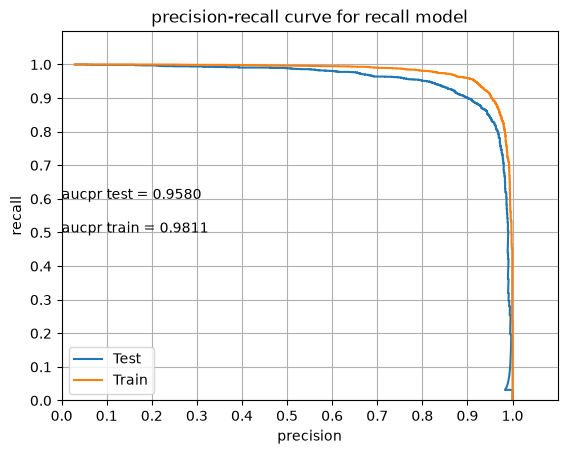

In [ ]:
# Plotting the precision-recall curve for our model. We ensure our model is not overtrained since the test curve (blue) is beneath the train curve (orange).
# We additionally get the aucpr (area under the precision-recall curve) values. A perfect model would give an aucpr value of 1.
fig, ax = plot_precision_recall_curve(model_recall, train_prov, test_prov)
plt.title('precision-recall curve for recall model')

In [ ]:
model_recall.save_model(path_+"recall_model.json") #Saving our model into a destination and with a name of our choice

### Performing the hyperparameter search

In [ ]:
# Defining the objective function using the XGBClassifier. We need this function in order to perform the hyperparameter search.
def objective_recall(space):
#Inside the function we define and fit an XGBoost classifier model just like we did before. Using the recall metric in this case.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain'
                          )

    evaluation = [(train[cols], train['label']),(test[cols],test['label'])]

    model.set_params(custom_metric = recall_eval, early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    rec = recall_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", rec) #We print the result from the recall metric.
    return {'loss': -rec, 'status': STATUS_OK}

There exist two kinds of hyperparameters, performance hyperparameters and regularization hyperparameters. We perform a hyperparameter search for each of them.

There are a few different ways to perform a hyperparameter search. In this case, we will use a method called bayesian optimization.

### Performance hyperparameters

In [ ]:
# The possible values are now given by the hyperopt hp function
max_leaves_s = np.arange(1, 100+1, dtype=int)
max_depth_s = np.arange(3, 10+1, dtype=int)

#We define the hyperparameter space. We will only perform the hyperaparameter search for this hyperparameters (max_leaves, max_depth)
param_space_per = {
           'max_leaves': hp.choice('max_leaves', max_leaves_s),
           'max_depth': hp.choice('max_depth', max_depth_s),
           }

In [ ]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_recall, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.884

In [ ]:
print(best_per_hyperparams)

{'max_depth': np.int64(5), 'max_leaves': np.int64(47)}


In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(47),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(47),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

In [ ]:
# In case that we have an already trained model saved, we can load it uncommenting the following code.
# loaded_model = xgb.XGBClassifier() # Defining a variable as an XGBoost classifier
# loaded_model.load_model(path_+"optimized_recall_model_per_hparams.json") # Loading the model from the path where it is saved

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_recall.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_recall.predict_proba(train[cols])[:,1])

Own ks test

	0.9511755513682877
	0.13093724177424346


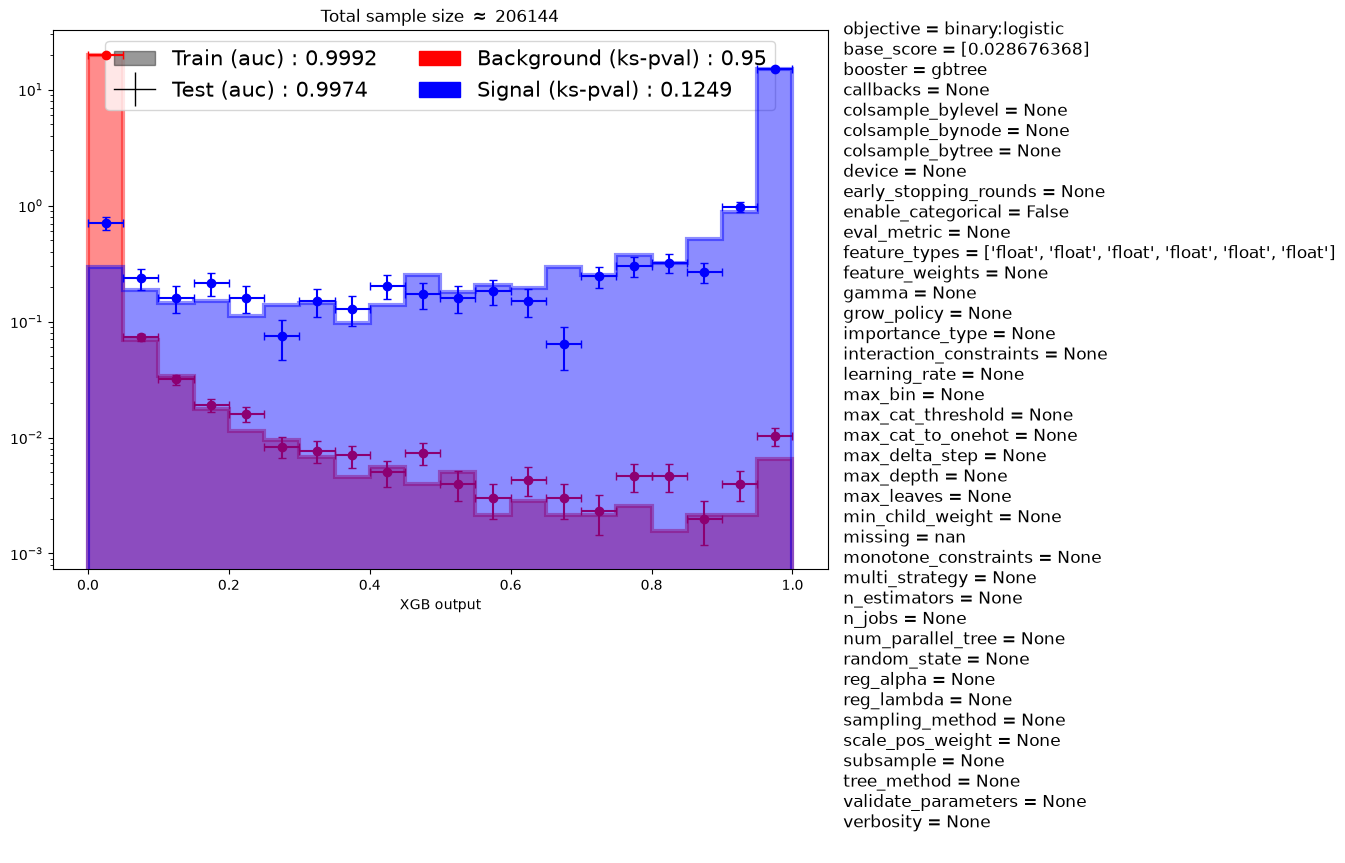

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_recall, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()
#We can see from these results that the pval from the signal DataFrame enhanced but sacrificing the pval from the background. However, now both account as acceptable pvals.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

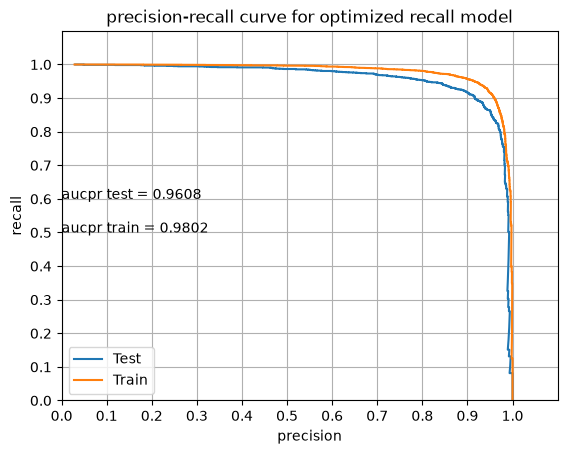

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_recall, train_prov, test_prov)
plt.title('precision-recall curve for optimized recall model')
# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_recall.save_model(path_+"optimized_recall_model_per_hparams.json") #Saving our model into a destination and with a name of our choice

### Regularization hyperparameters

In [ ]:
reg_alpha_s= np.arange(0, 10, 1)
reg_lambda_s= np.arange(0, 10, 1)

#Defining the hyperparameter space
param_space_reg = {
    'reg_alpha': hp.choice('reg_alpha', reg_alpha_s),
    'reg_lambda': hp.choice('reg_lambda', reg_lambda_s),
}

In [ ]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_recall, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.8847802786709539
SCORE:
0.884

In [ ]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(9), 'reg_lambda': np.int64(9)}


In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

### Evaluation

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_recall.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_recall.predict_proba(train[cols])[:,1])

Own ks test

	0.8437417339042876
	0.7133245295863159


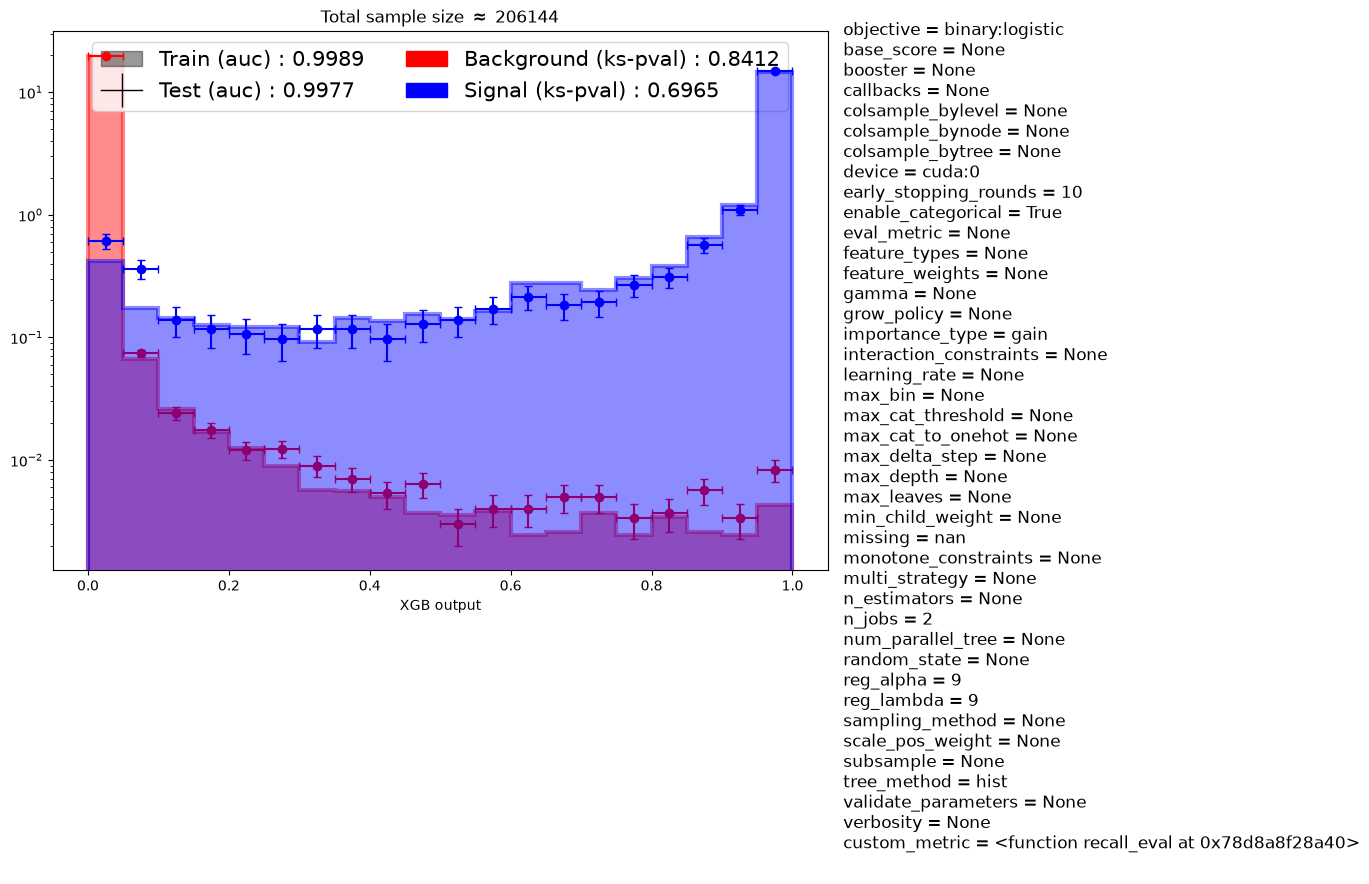

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_recall, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()


#We can see from these results that the pval from the signal DataFrame enhanced but sacrificing the pval from the background. However, now both account as acceptable pvals.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

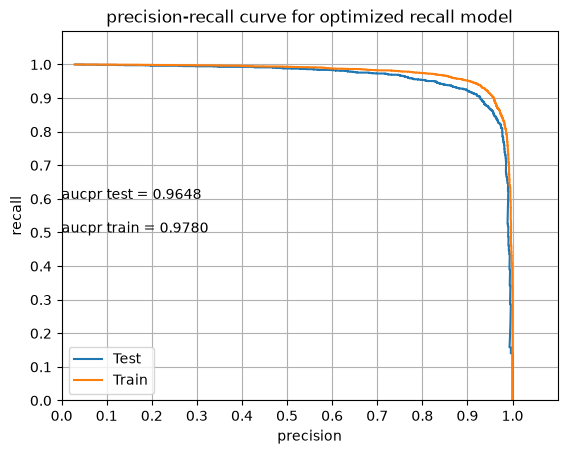

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_recall, train_prov, test_prov)
plt.title('precision-recall curve for optimized recall model')


# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_recall.save_model(path_+"optimized_recall_model_reg_hparams.json") #Saving our model into a destination and with a name of our choice

### Mixed hyperparameters

In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_recall = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_recall.set_params(custom_metric = recall_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(47),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_recall.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function recall_eval at 0x78d8a8f28a40>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=np.int64(47),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_recall.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_recall.predict_proba(train[cols])[:,1])

Own ks test

	0.33635014600322855
	0.5819878623941869


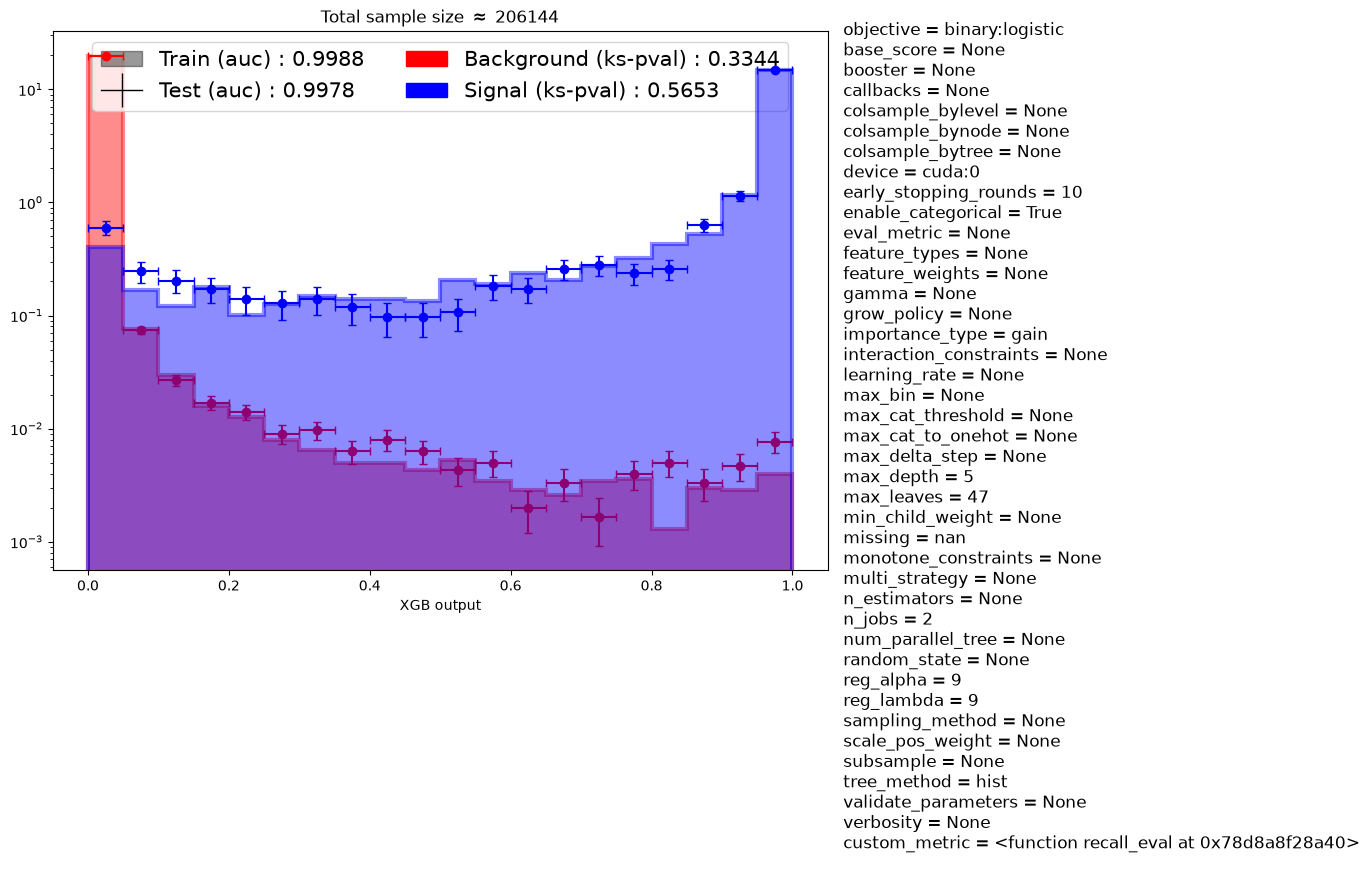

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_recall, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()


#We can see from these results that the pval from the signal DataFrame enhanced but sacrificing the pval from the background. However, now both account as acceptable pvals.

Text(0.5, 1.0, 'precision-recall curve for optimized recall model')

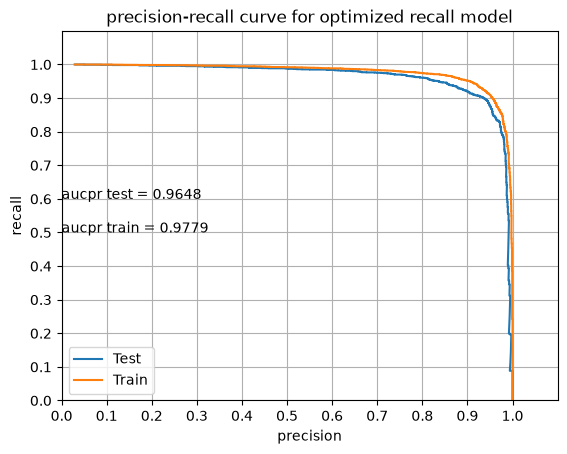

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_recall, train_prov, test_prov)
plt.title('precision-recall curve for optimized recall model')


# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_recall.save_model(path_+"optimized_recall_model_mixed_hparams.json") #Saving our model into a destination and with a name of our choice

# **Precision metric**

The processes of model creation, training and hyperparameter tuning will be analogous to those performed for recall metric. With a few exceptions that will be noted through comments. Other comments will be reduced or eliminated to avoid redundancy.

### First XGB precision model

In [ ]:
# Creating an XGBoost model
model_precision = xgb.XGBClassifier(objective='binary:logistic',
                         tree_method = 'hist',
                         device="cuda:0",
                         n_jobs=os.cpu_count(),
                         importance_type = 'gain'
                      )

In [ ]:
# Defining parameters for our model.
model_precision.set_params(custom_metric = precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [ ]:
# Training the model with our data using the recall metric
model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

{'Bpt': 0.021353496238589287,
 'PDL': 0.020199788734316826,
 'cosA': 0.6167211532592773,
 'kpt': 0.18459674715995789,
 'prob': 0.037120237946510315,
 'signLxy': 0.12000858038663864}


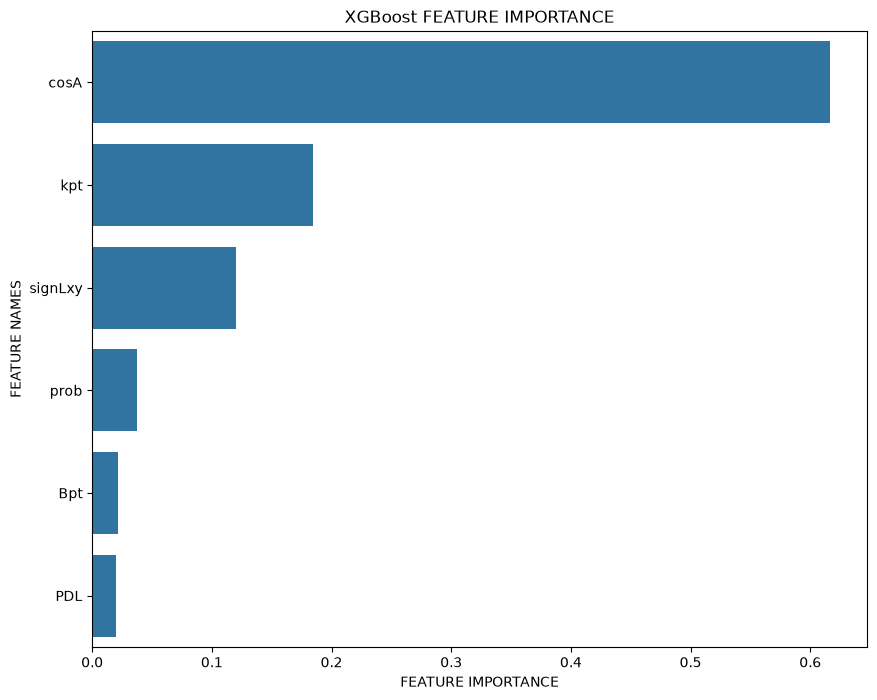

In [ ]:
# Plotting feature importances.
plot_feature_importance(model_precision.feature_importances_, train[cols].columns, "XGBoost")

### Evaluation

In [ ]:
#Computing probabilities for events to be signal in test and train DataFrames
test_prov = test.assign(XGB=model_precision.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=model_precision.predict_proba(train[cols])[:,1])

Own ks test

	0.8560873777461462
	0.05659666627921


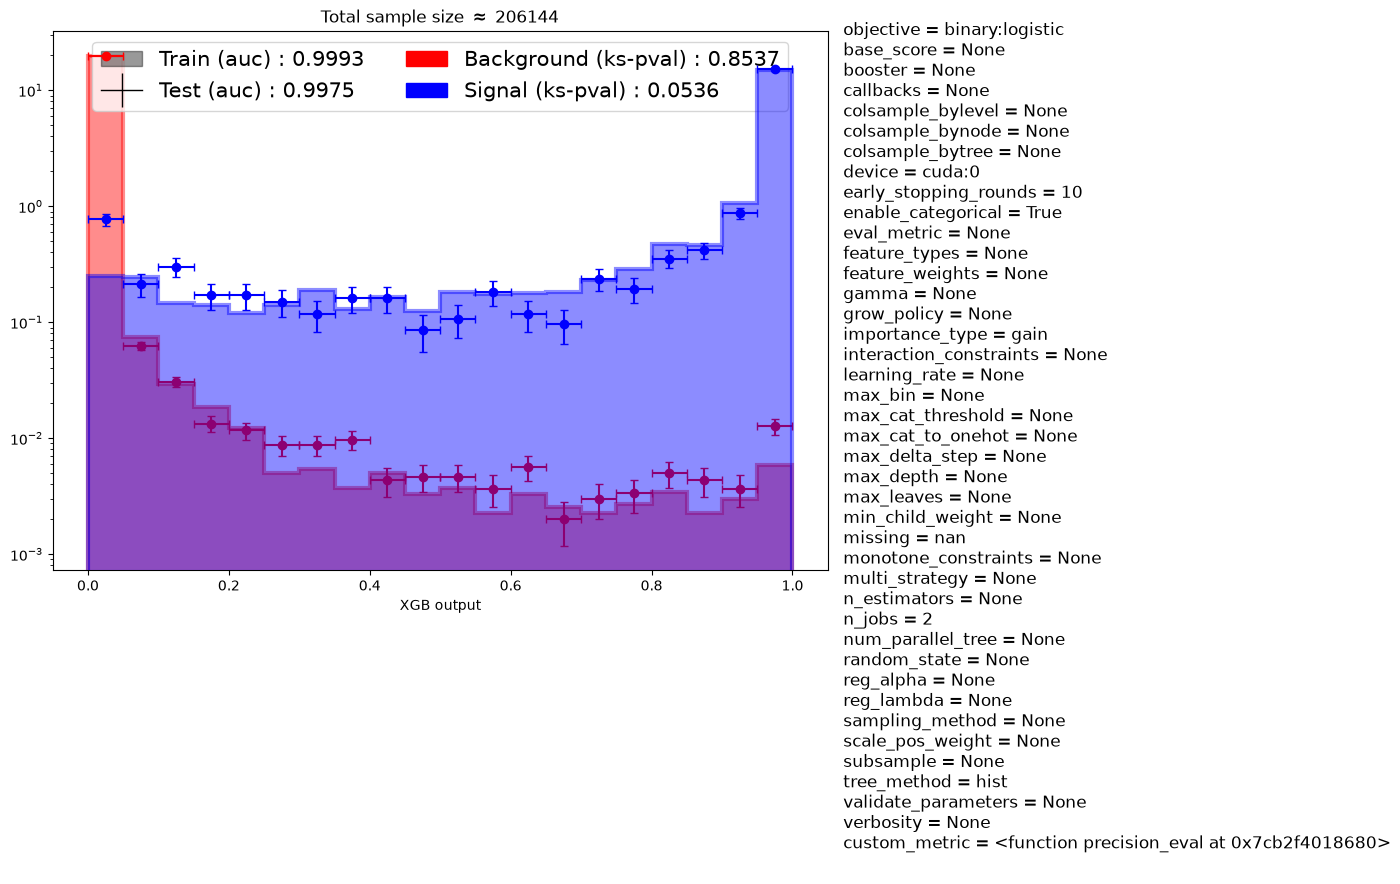

In [ ]:
# Plotting classifier distributions
fig, ax = plot_classifier_distributions(model_precision, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for precision model')

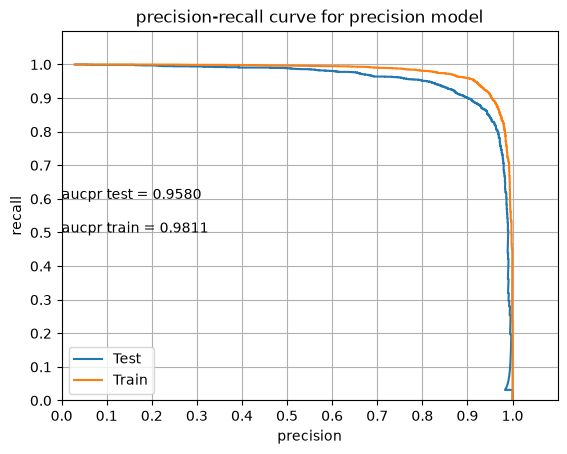

In [ ]:
# Plotting the precision-recall curve for our model.
fig, ax = plot_precision_recall_curve(model_precision, train_prov, test_prov)
plt.title('precision-recall curve for precision model')

In [ ]:
model_precision.save_model(path_+"precision_model.json") #Saving our model into a destination and with a name of our choice

### Performing the hyperparameter search

In [ ]:
# Defining the objective function using the XGBClassifier.
def objective_precision(space):
#We define and fit an XGBoost classifier model.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain'
                          )

    model.set_params(custom_metric = precision_eval, early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    prec = precision_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", prec) #We print the result from the precision metric.
    return {'loss': -prec, 'status': STATUS_OK}

### Performance hyperparameters

In [ ]:
# The possible values are now given by the hyperopt hp function
max_leaves_s = np.arange(1, 100+1, dtype=int)
max_depth_s = np.arange(3, 10+1, dtype=int)

#We define the hyperparameter space.
param_space_per = {
           'max_leaves': hp.choice('max_leaves', max_leaves_s),
           'max_depth': hp.choice('max_depth', max_depth_s),
           }

In [ ]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_precision, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.919

In [ ]:
print(best_per_hyperparams)

{'max_depth': np.int64(7), 'max_leaves': np.int64(52)}


In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(7), max_leaves=np.int64(52),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(7), max_leaves=np.int64(52),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_precision.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_precision.predict_proba(train[cols])[:,1])

Own ks test

	0.8568429024600946
	0.001727445291100449


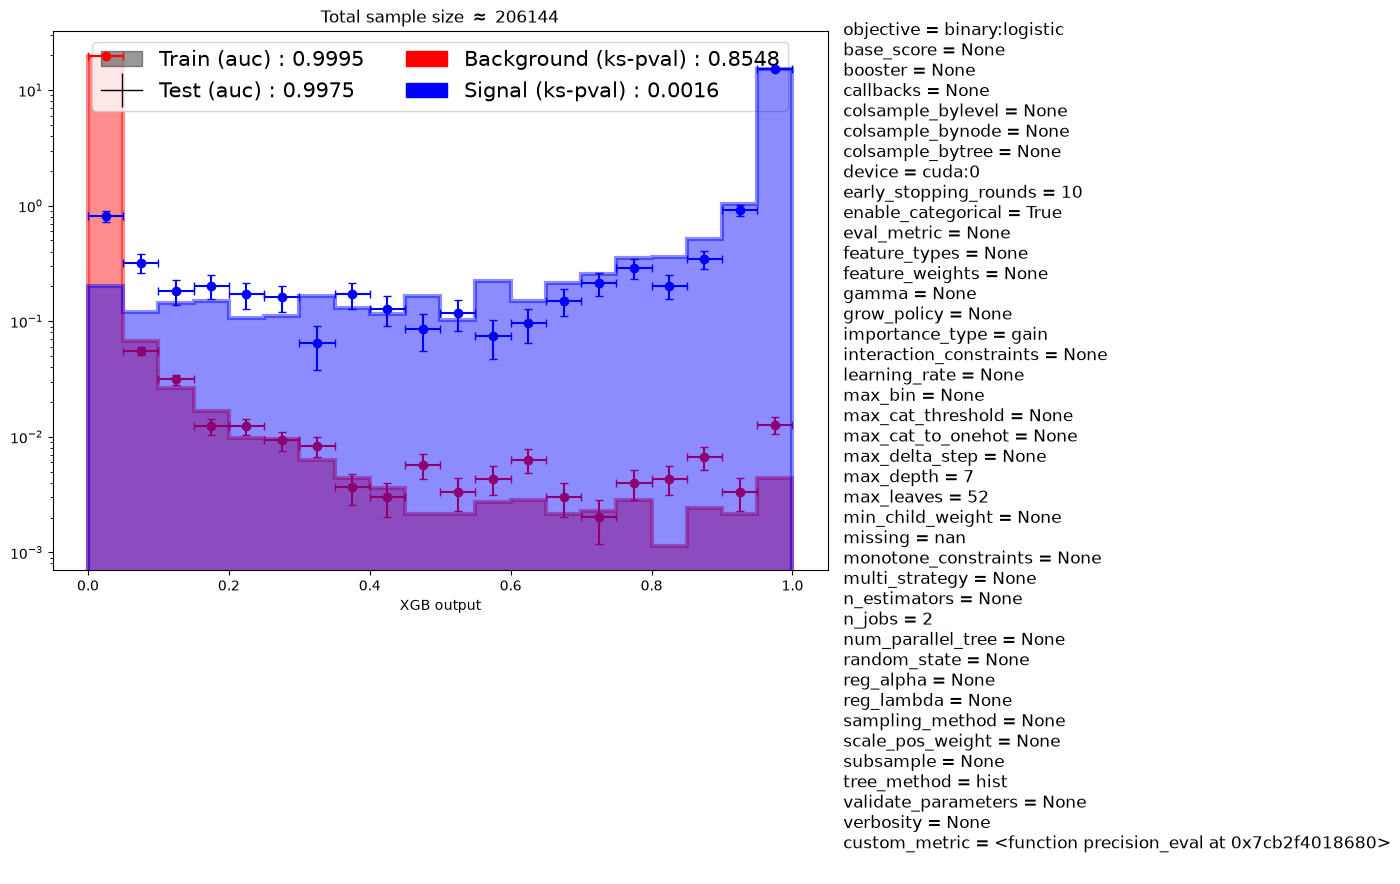

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_precision, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

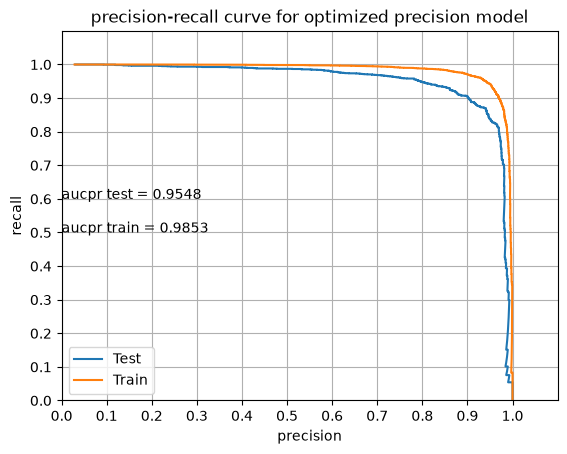

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_precision, train_prov, test_prov)
plt.title('precision-recall curve for optimized precision model')
# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_precision.save_model(path_+"optimized_precision_model_per_hparams.json") #Saving our model into a destination and with a name of our choice

### Regularization hyperparameters

In [ ]:
reg_alpha_s= np.arange(0, 10, 1)
reg_lambda_s= np.arange(0, 10, 1)

#Defining the hyperparameter space
param_space_reg = {
    'reg_alpha': hp.choice('reg_alpha', reg_alpha_s),
    'reg_lambda': hp.choice('reg_lambda', reg_lambda_s),
}

In [ ]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_precision, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.9197771587743733
SCORE:
0.919

In [ ]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(4), 'reg_lambda': np.int64(9)}


In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, ...)

### Evaluation

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_precision.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_precision.predict_proba(train[cols])[:,1])

Own ks test

	0.7501028454683365
	0.42436455640006493


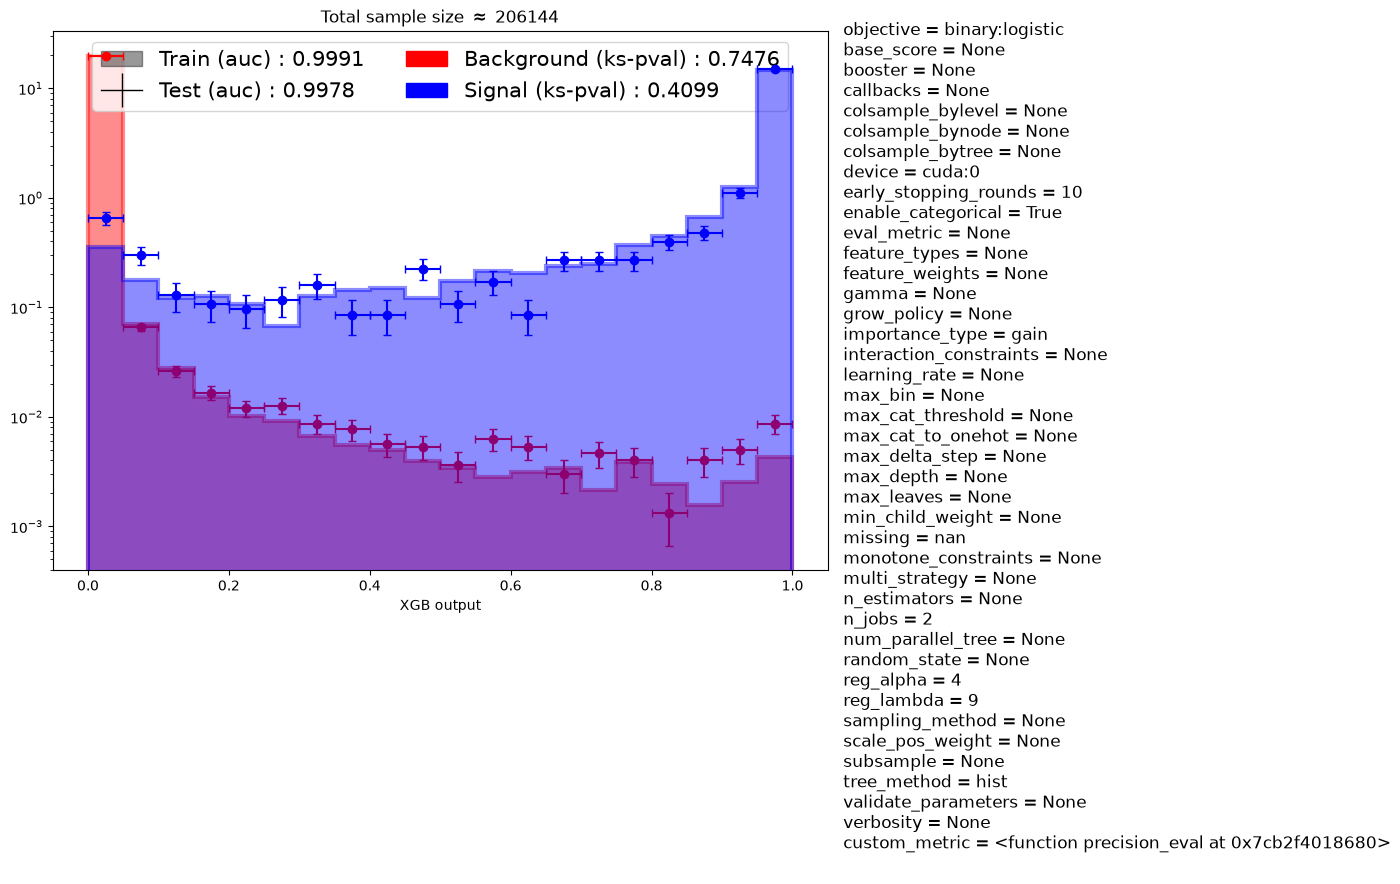

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_precision, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

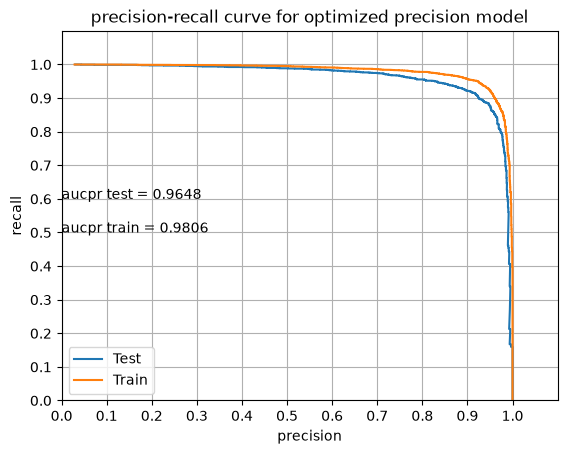

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_precision, train_prov, test_prov)
plt.title('precision-recall curve for optimized precision model')
# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_precision.save_model(path_+"optimized_precision_model_reg_hparams.json") #Saving our model into a destination and with a name of our choice

### Mixed hyperparameters

In [ ]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_precision = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_precision.set_params(custom_metric = precision_eval, early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(7), max_leaves=np.int64(52),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

In [ ]:
# Training the new optimized model
opt_model_precision.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,
              custom_metric=<function precision_eval at 0x7cb2f4018680>,
              device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(7), max_leaves=np.int64(52),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2, ...)

### Evaluation

In [ ]:
#Obtaining the predicted probabilities for the test and train DataFrames
test_prov = test.assign(XGB=opt_model_precision.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_precision.predict_proba(train[cols])[:,1])

Own ks test

	0.9043211631745495
	0.19387674765597185


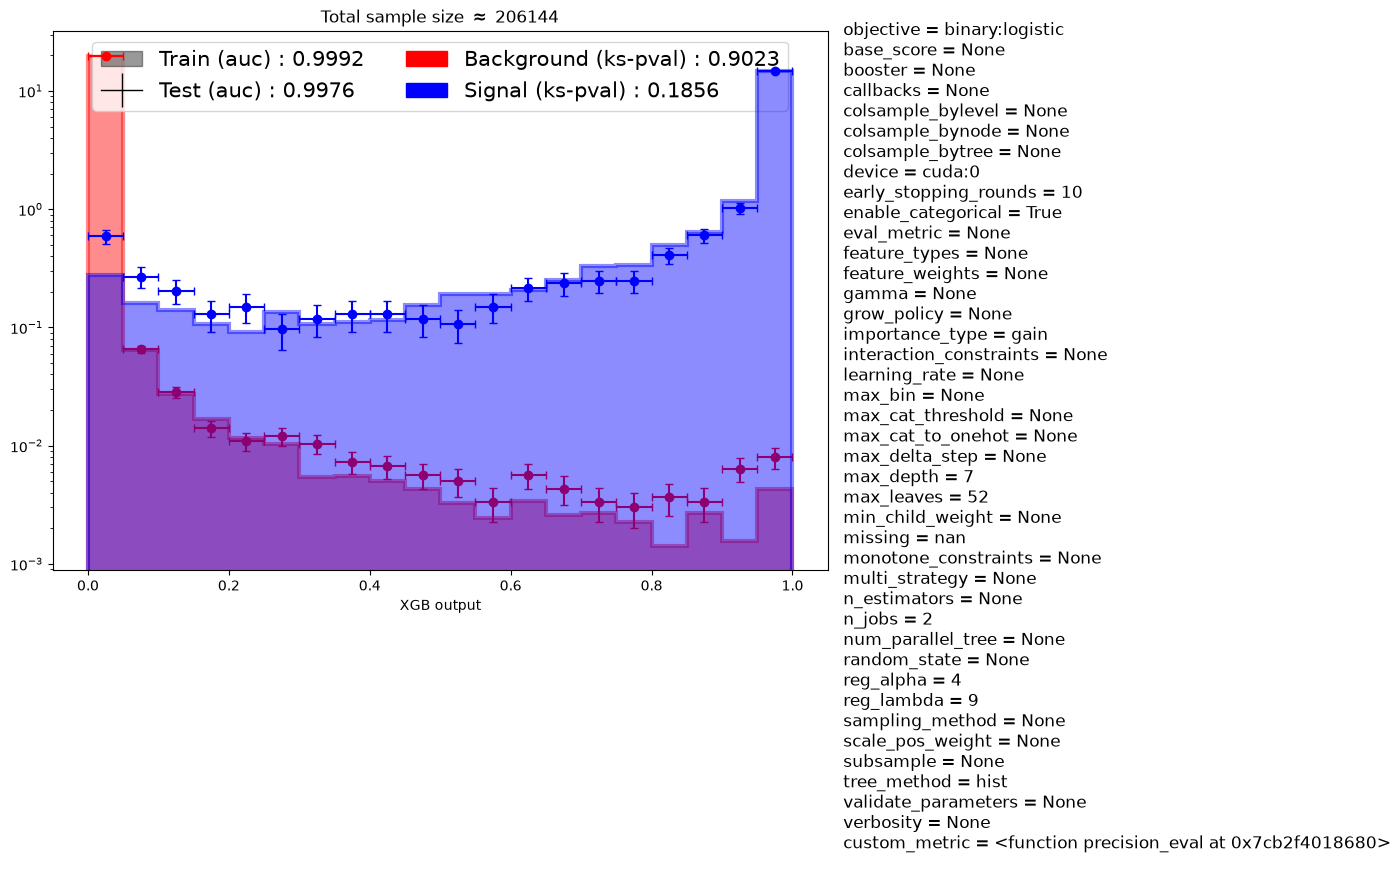

In [ ]:
# Poltting the classifier distributions
fig, ax = plot_classifier_distributions(opt_model_precision, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

Text(0.5, 1.0, 'precision-recall curve for optimized precision model')

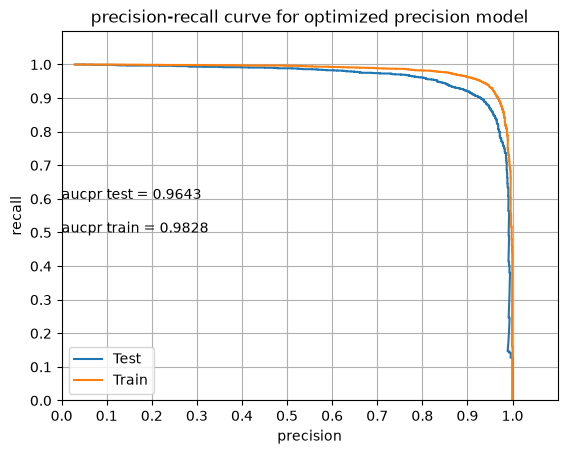

In [ ]:
# Plotting the precision-recall curve and obtaining the aucpr results
fig, ax = plot_precision_recall_curve(opt_model_precision, train_prov, test_prov)
plt.title('precision-recall curve for optimized precision model')
# From the results of the test curve we can see that the aucpr values increased, thus the optimized model enhanced the predictability for precision and recall.
# On the other hand, the test curve is still beneath the train curve, so there is still no overtraining.

In [ ]:
opt_model_precision.save_model(path_+"optimized_precision_model_mixed_hparams.json") #Saving our model into a destination and with a name of our choice

# **AUC metric**

### First XGB AUC model

In [20]:
# Creating an XGBoost model
model_auc = xgb.XGBClassifier(objective='binary:logistic',
                         tree_method = 'hist',
                         device="cuda:0",
                         n_jobs=os.cpu_count(),
                         importance_type = 'gain',
                         eval_metric='auc' #In this case, the metric is included in XGBoost, so we add it inside the XGB classifier definition
                      )

In [21]:
# Defining parameters for our model.
model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

In [22]:
# Training the model with our data using the recall metric
model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

{'Bpt': 0.02151486650109291,
 'PDL': 0.019993692636489868,
 'cosA': 0.6139949560165405,
 'kpt': 0.1854386180639267,
 'prob': 0.037098538130521774,
 'signLxy': 0.12195927649736404}


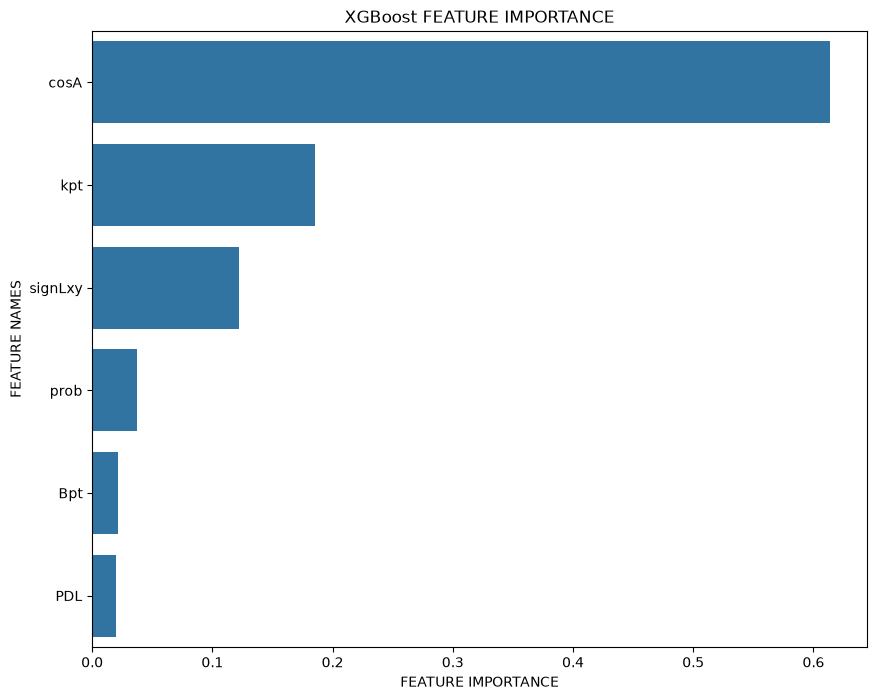

In [23]:
# Plotting feature importances.
plot_feature_importance(model_auc.feature_importances_, train[cols].columns, "XGBoost")

### Evaluation

In [24]:
#Computing probabilities for events to be signal in test and train DataFrames
test_prov = test.assign(XGB=model_auc.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=model_auc.predict_proba(train[cols])[:,1])

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [00:01:20] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Own ks test

	0.7193380735693549
	0.05230528103078357


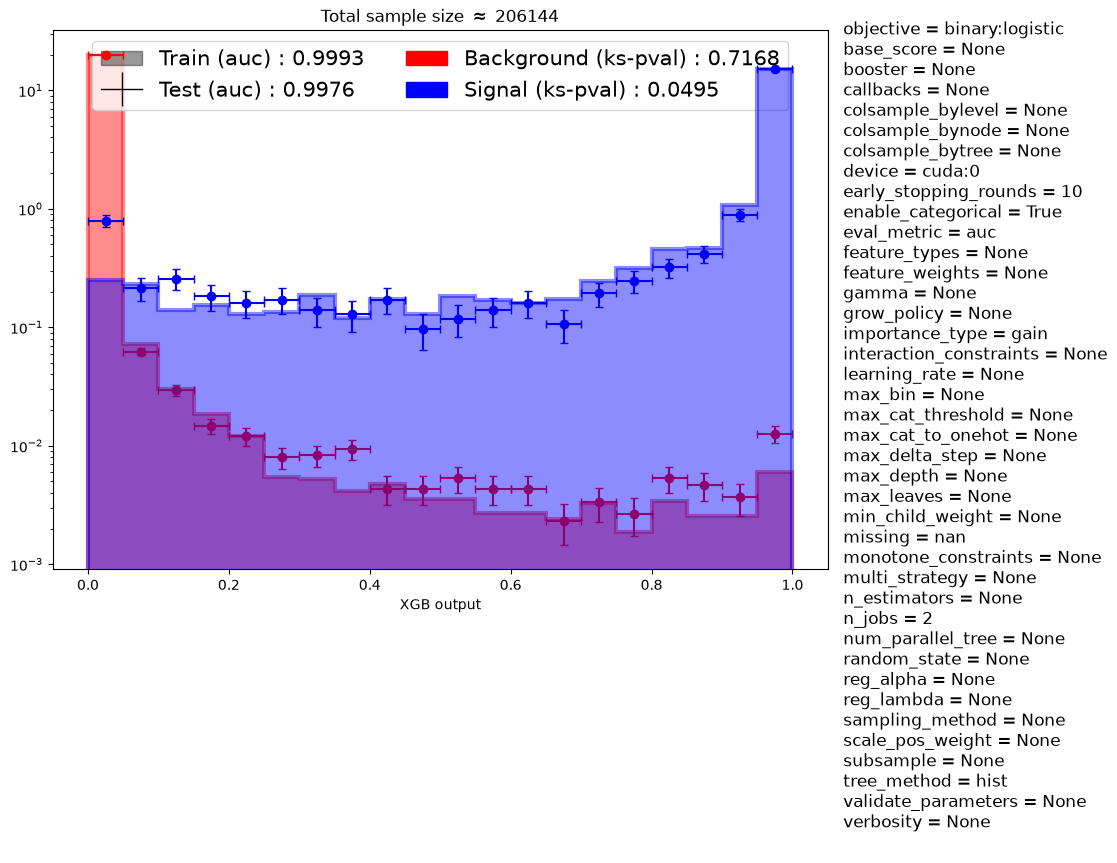

In [25]:
# Plotting classifier distributions
fig, ax = plot_classifier_distributions(model_auc, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

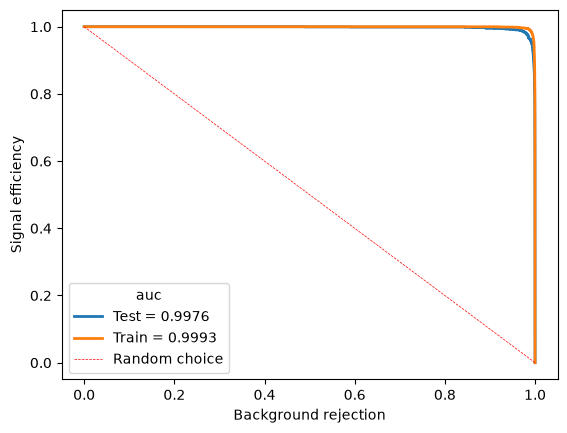

In [39]:
plot_roc_curve(model_auc, test, train)

### Performing the hyeprparameter search

In [27]:
# Defining the objective function using the XGBClassifier.
def objective_auc(space):
#We define and fit an XGBoost classifier model.
    model=xgb.XGBClassifier(objective='binary:logistic',
                          tree_method = 'hist',
                          device="cuda:0",
                          n_jobs=os.cpu_count(),
                          importance_type = 'gain',
                          eval_metric='auc'
                          )

    model.set_params(early_stopping_rounds=10)

    model.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)


    pred = model.predict(test[cols]) #Additionally we obtain the predicted probabilities from our model.
    auc = roc_auc_score(test['label'], pred>0.5) #We calculate the recall score from the test DataFrame using the recall_score from sklearn.metrics
    print ("SCORE:", auc) #We print the result from the auc metric.
    return {'loss': -auc, 'status': STATUS_OK}

### Performance hyperparameters

In [28]:
# The possible values are now given by the hyperopt hp function
max_leaves_s = np.arange(1, 100+1, dtype=int)
max_depth_s = np.arange(3, 10+1, dtype=int)

#We define the hyperparameter space.
param_space_per = {
           'max_leaves': hp.choice('max_leaves', max_leaves_s),
           'max_depth': hp.choice('max_depth', max_depth_s),
           }

In [29]:
#Performing the hyperparameter search with the fmin function from the hyperopt library. Using the bayesian optimization method.
best_per_hyperparams = fmin(fn = objective_auc, #Specifiying the objective function to use
                        space = param_space_per, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765


In [43]:
print(best_per_hyperparams)

{'max_depth': np.int64(0), 'max_leaves': np.int64(57)}


In [31]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance,
                         eval_metric= 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(0), max_leaves=np.int64(57),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

In [32]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(0), max_leaves=np.int64(57),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

### Evaluation

In [33]:
#Computing probabilities for events to be signal in test and train DataFrames
test_prov = test.assign(XGB=opt_model_auc.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_auc.predict_proba(train[cols])[:,1])

Own ks test

	0.8357116151793623
	0.03170398885399926


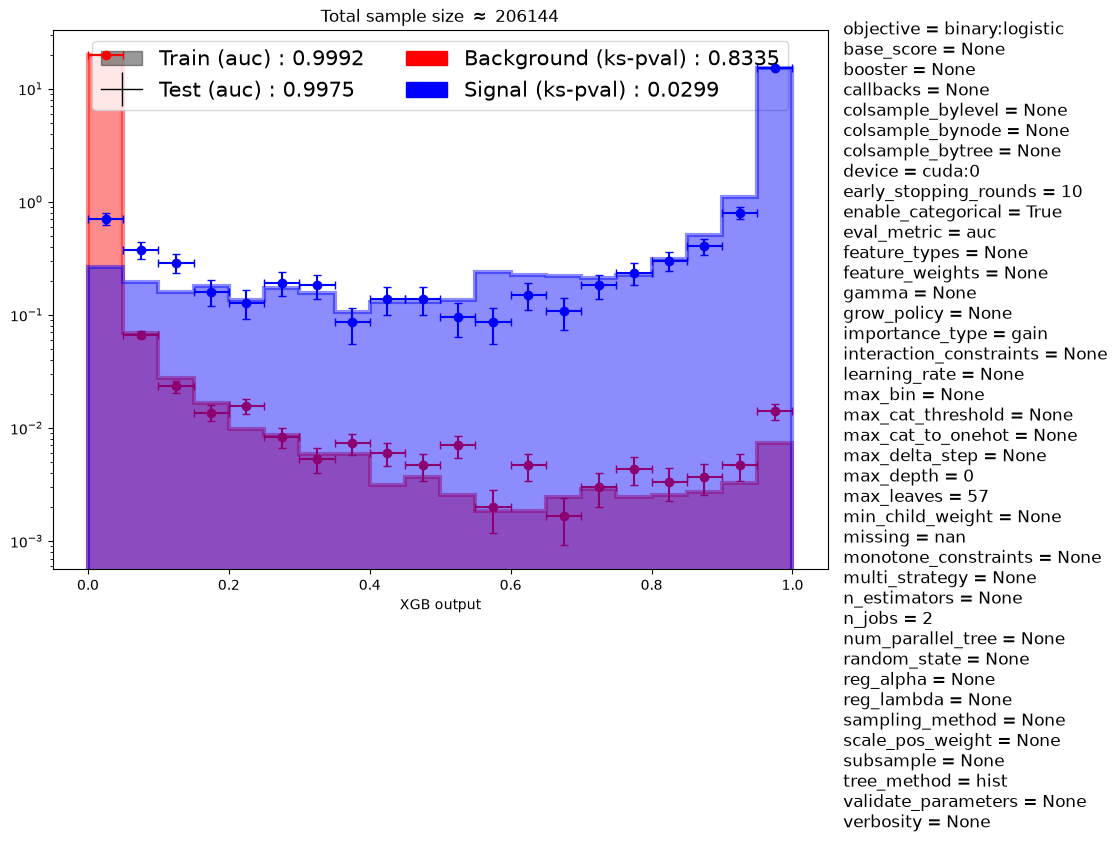

In [34]:
# Plotting classifier distributions
fig, ax = plot_classifier_distributions(opt_model_auc, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

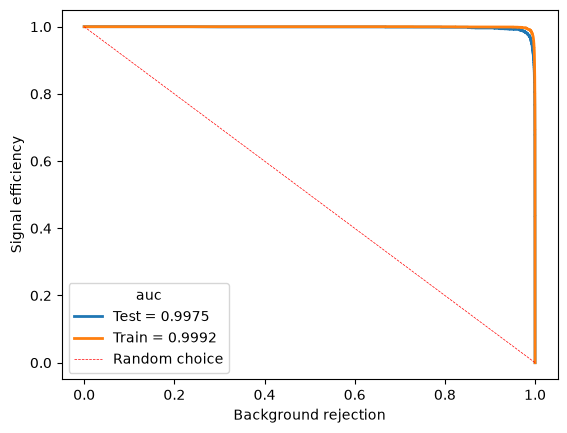

In [40]:
plot_roc_curve(opt_model_auc, test, train)

### Regularization hyperparameters

In [41]:
reg_alpha_s= np.arange(0, 10, 1)
reg_lambda_s= np.arange(0, 10, 1)

#Defining the hyperparameter space
param_space_reg = {
    'reg_alpha': hp.choice('reg_alpha', reg_alpha_s),
    'reg_lambda': hp.choice('reg_lambda', reg_lambda_s),
}

In [42]:
#Performing the hyperparameter search.
best_reg_hyperparams = fmin(fn = objective_auc, #Specifiying the objective function to use
                        space = param_space_reg, #Using the hyperparameter space previously defined.
                        algo = tpe.suggest, # Using the Tree-structured Parzen Estimator function from hyperopt as algorithm
                        max_evals = 100, # The maximum number of trials (or evaluations) the optimization algorithm will conduct
                        )

SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765
SCORE:
0.940905073553765


In [44]:
print(best_reg_hyperparams)

{'reg_alpha': np.int64(5), 'reg_lambda': np.int64(7)}


In [45]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance,
                         eval_metric= 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

In [46]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=2, num_parallel_tree=None, ...)

### Evaluation

In [47]:
#Computing probabilities for events to be signal in test and train DataFrames
test_prov = test.assign(XGB=opt_model_auc.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_auc.predict_proba(train[cols])[:,1])

Own ks test

	0.8365545942974865
	0.5337647605307929


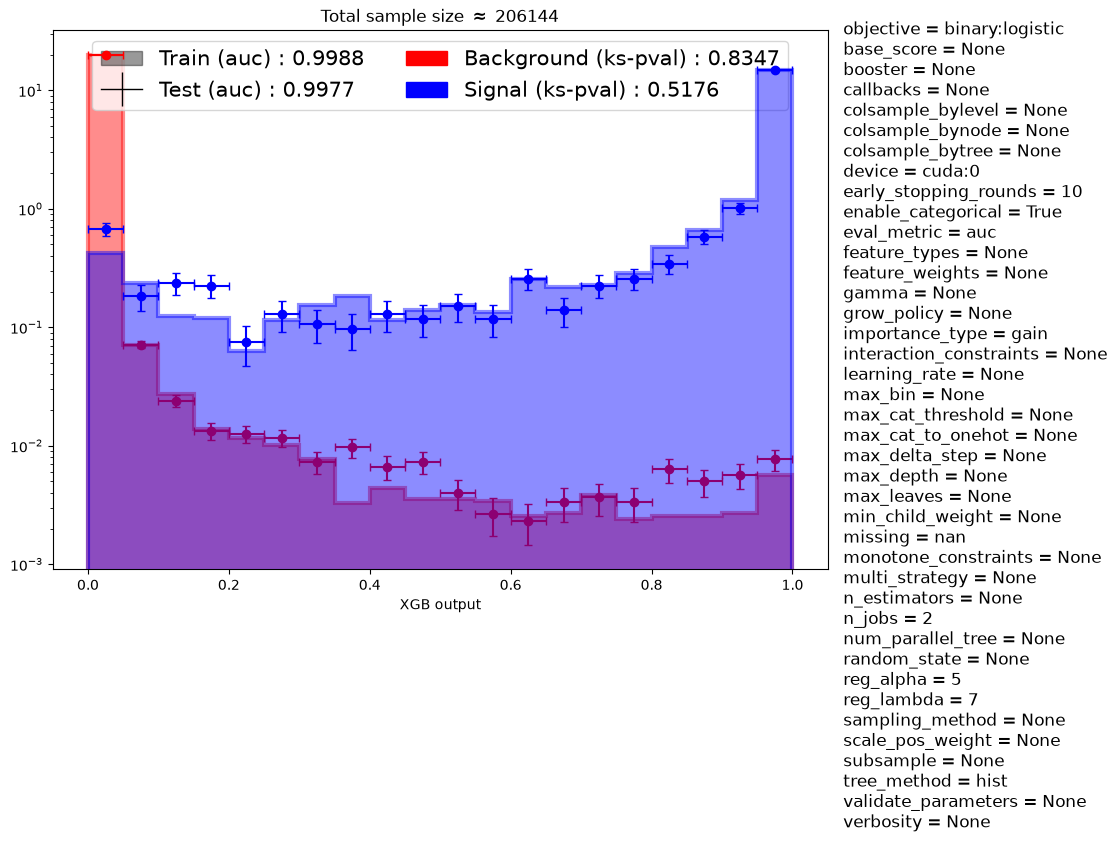

In [48]:
# Plotting classifier distributions
fig, ax = plot_classifier_distributions(opt_model_auc, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

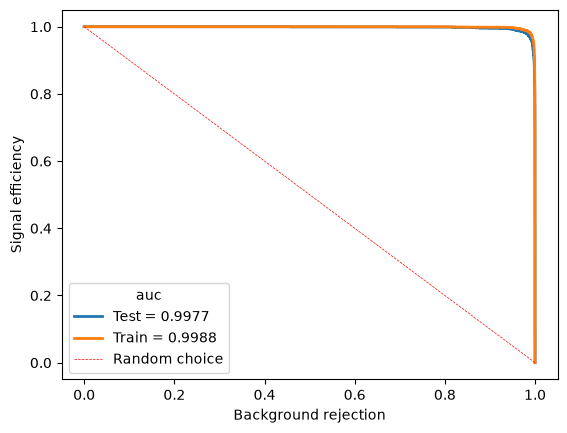

In [50]:
plot_roc_curve(opt_model_auc, test, train)

### Mixed hyperparameters

In [51]:
# Creating an XGBoost model with the optimized hyperparameters
opt_model_auc = xgb.XGBClassifier(objective='binary:logistic', # Logistic regression for binary classification the output is a probability
                         tree_method = 'hist', # This tree method uses gpu, is faster and uses less memory
                         device="cuda:0", # It specifies which GPU to use for training
                         n_jobs=os.cpu_count(), # Using every available CPU we can also use n_jobs=-1
                         importance_type = 'gain', # Dictates the metric to calculate feature importance
                         eval_metric = 'auc',
                         #Using the hyperparameter values obtained from the hyperparameter search
                         max_depth = best_per_hyperparams['max_depth'],
                         max_leaves = best_per_hyperparams['max_leaves'],
                         reg_alpha = best_reg_hyperparams['reg_alpha'],
                         reg_lambda = best_reg_hyperparams['reg_lambda']
                      )

# Adding the pertinent parameters just like before
opt_model_auc.set_params(early_stopping_rounds=10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(0), max_leaves=np.int64(57),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

In [52]:
# Training the new optimized model
opt_model_auc.fit(train[cols], train['label'], eval_set=evaluation, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type='gain', interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(0), max_leaves=np.int64(57),
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=2,
              num_parallel_tree=None, ...)

### Evaluation

In [53]:
#Computing probabilities for events to be signal in test and train DataFrames
test_prov = test.assign(XGB=opt_model_auc.predict_proba(test[cols])[:,1])
train_prov = train.assign(XGB=opt_model_auc.predict_proba(train[cols])[:,1])

Own ks test

	0.17275006174711452
	0.057169021632336885


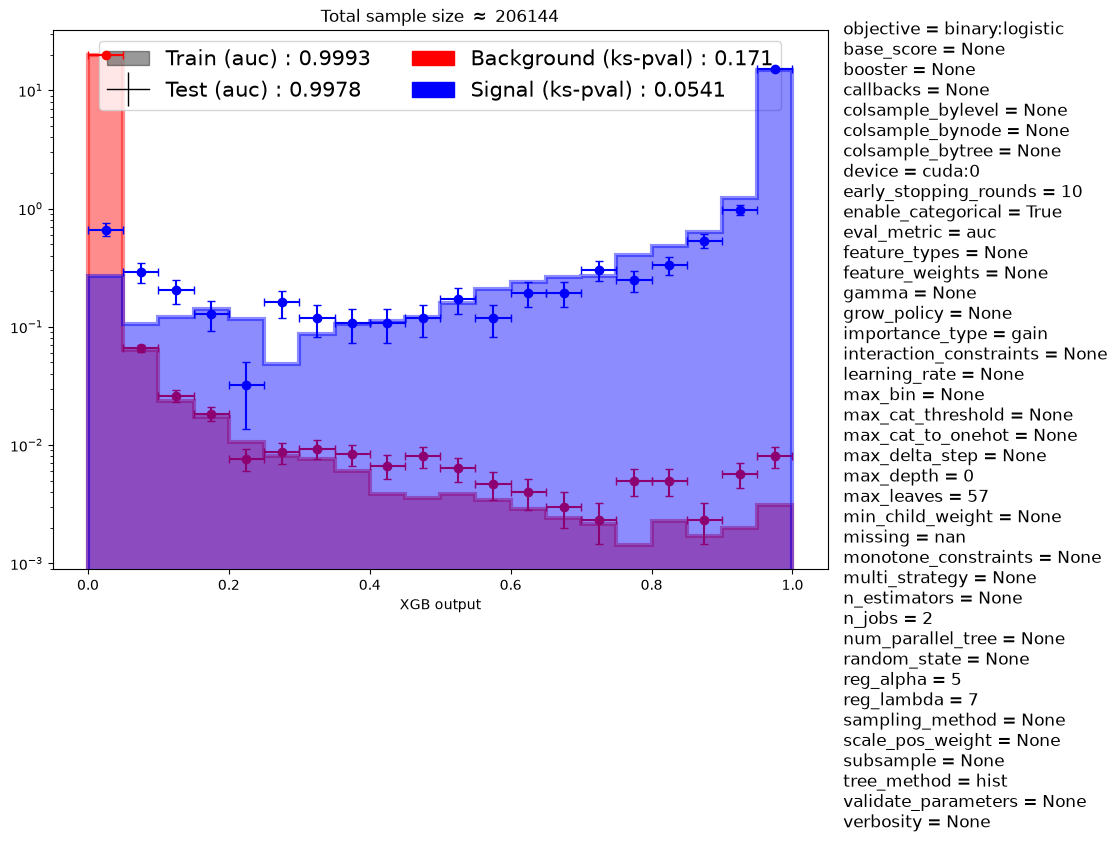

In [54]:
# Plotting classifier distributions
fig, ax = plot_classifier_distributions(opt_model_auc, test=test_prov, train=train_prov, print_params=True)
ax.set_title(r'Total sample size $\approx$ '+str(sample_size))
plt.show()

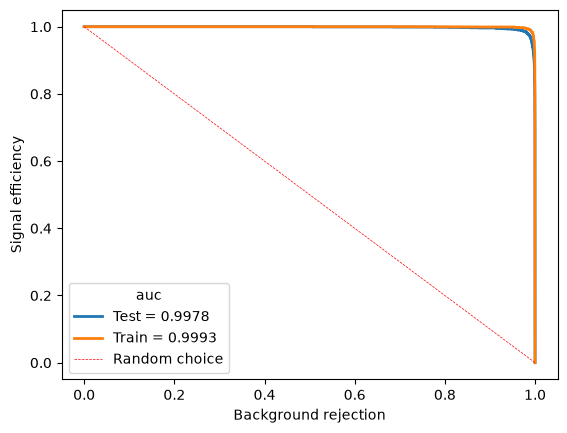

In [55]:
plot_roc_curve(opt_model_auc, test, train)